In [1]:
import pandas as pd
print("Setup Complete")

Setup Complete


In [2]:
import pandas as pd
import numpy as np
import random

# Seed for reproducibility
np.random.seed(42)

# 1. Define Meghalaya-specific constants
districts = [
    'East Khasi Hills', 'West Garo Hills', 'Ri-Bhoi', 
    'West Jaintia Hills', 'East Garo Hills', 'South West Khasi Hills'
]
land_types = ['Clan Land (Ri-Kynti)', 'Community Land (Ri-Raid)', 'Private Revenue Land', 'Government Forest']
dispute_types = ['None', 'Boundary Dispute', 'Inheritance', 'Encroachment']

# 2. Generate 500 fake records
data_size = 500
df = pd.DataFrame({
    'land_id': range(1001, 1001 + data_size),
    'district': np.random.choice(districts, data_size),
    'land_type': np.random.choice(land_types, data_size, p=[0.4, 0.4, 0.1, 0.1]),
    'area_acres': np.round(np.random.exponential(scale=5, size=data_size), 2),
    'distance_to_highway_km': np.round(np.random.uniform(0.1, 50, data_size), 1),
    'has_proper_survey': np.random.choice([0, 1], data_size, p=[0.6, 0.4]), # 0=No, 1=Yes
    'dispute_status': np.random.choice(dispute_types, data_size, p=[0.6, 0.2, 0.1, 0.1])
})

# 3. Save this to your "Raw Data" folder
# Note: We use '..' to go back one folder from 'notebooks' to the root, then into 'data/raw'
output_path = '../data/raw/synthetic_meghalaya_land_data.csv'
df.to_csv(output_path, index=False)

print(f"Success! Synthetic data saved to: {output_path}")
print(df.head())

Success! Synthetic data saved to: ../data/raw/synthetic_meghalaya_land_data.csv
   land_id            district                 land_type  area_acres  \
0     1001  West Jaintia Hills      Clan Land (Ri-Kynti)        0.98   
1     1002     East Garo Hills  Community Land (Ri-Raid)       16.23   
2     1003             Ri-Bhoi      Clan Land (Ri-Kynti)        0.80   
3     1004     East Garo Hills  Community Land (Ri-Raid)        2.68   
4     1005     East Garo Hills  Community Land (Ri-Raid)        0.45   

   distance_to_highway_km  has_proper_survey    dispute_status  
0                    43.4                  0              None  
1                    36.4                  1              None  
2                    37.2                  1      Encroachment  
3                    21.3                  0  Boundary Dispute  
4                    17.4                  0  Boundary Dispute  


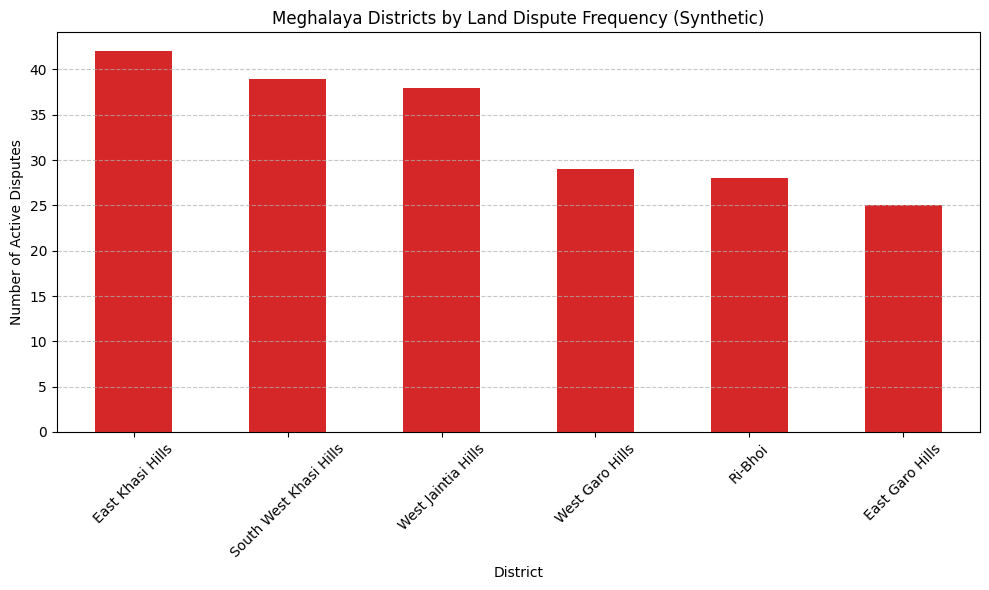

In [3]:
import matplotlib.pyplot as plt

# 1. Filter for actual disputes (ignore "None")
actual_disputes = df[df['dispute_status'] != 'None']

# 2. Count disputes per district
risk_counts = actual_disputes['district'].value_counts()

# 3. Plot the danger map
plt.figure(figsize=(10,6))
risk_counts.plot(kind='bar', color='#d62728') # Red for danger
plt.title('Meghalaya Districts by Land Dispute Frequency (Synthetic)')
plt.xlabel('District')
plt.ylabel('Number of Active Disputes')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()